# Realized Volatility Timing — Rendu projet

## Vue d'ensemble du projet

Ce notebook implémente un système de **timing de volatilité** en deux parties :

### Partie 1 — Backtest de stratégies optionnelles avec delta/gamma hedging
- Génération de positions via `OptionTrade`, `DeltaHedgedOptionTrade`, `DeltaGammaHedgedOptionTrade`
- Backtest P&L décomposé (delta, gamma, theta, vega, résiduel)
- Comparaison avec/sans coûts de transaction (`BacktesterBidAskFromData`, `BacktesterFixedRelativeBidAsk`)

### Partie 2 — Nowcasting de la volatilité réalisée par Filtre de Kalman non-linéaire (UKF)
- Modèle de Heston en espace d'état sur les log-returns
- Unscented Kalman Filter avec correction exacte de la corrélation ρ
- Construction du spread s_t = σ_IV,t − σ̂_t
- Allocation dynamique des stratégies de carry vol selon s_t

### Dynamique de Heston (modèle continu)

$$\begin{cases}
dS_t = \mu S_t \, dt + S_t \sqrt{v_t} \, dW_{1,t} \\
dv_t = \kappa(\theta - v_t) \, dt + \xi \sqrt{v_t} \, dW_{2,t} \\
dW_{1,t} \cdot dW_{2,t} = \rho \, dt
\end{cases}$$

- $v_t$ est la **variance latente** (état caché)
- $S_t$ est le **prix spot observé** (observation)
- L'objectif est d'estimer $\hat{v}_t$ pour en déduire $\hat{\sigma}_t = \sqrt{\hat{v}_t}$
- Puis calculer le spread $s_t = \sigma_{IV,t} - \hat{\sigma}_t$ pour le timing

## 0 — Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("/Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/") 
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(sys.path[0])

/Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
print(sys.path[0])

/Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing


In [4]:
import logging
import warnings

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rc("font", **{"size": 16})
print(sys.path[0])

/Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing


In [5]:
#pip install filterpy

In [6]:
# Imports investment_lab
from investment_lab.data.option_db import OptionLoader, SPYOptionLoader, extract_spot_from_options
from investment_lab.data.rates_db import USRatesLoader
from investment_lab.rates import compute_forward
from investment_lab.metrics.volatility import rolling_realized_volatility
from investment_lab.metrics.util import levels_to_returns
from investment_lab.metrics.performance import sharpe_ratio, max_drawdown, calmar_ratio
from investment_lab import option_strategies

# Classes de backtest et de trading
from investment_lab.option_trade import (
    OptionTrade,
    DeltaHedgedOptionTrade,
    DeltaGammaHedgedOptionTrade,
)
from investment_lab.backtest import (
    StrategyBacktester,
    BacktesterBidAskFromData,
    BacktesterFixedRelativeBidAsk,
)

# UKF Heston
from investment_lab.heston_ukf import (
    HestonParams,
    HestonUKF,
    VolatilityTiming,
    build_timing_positions,
)



In [7]:
# ── Paramètres globaux ──────────────────────────────────────────────────────
START = datetime(2020, 1, 2)
END   = datetime(2022, 12, 30)
TICKER = "SPY"

print(f"Période : {START.date()} → {END.date()} | Ticker : {TICKER}")

Période : 2020-01-02 → 2022-12-30 | Ticker : SPY


---
## Partie 1 — Backtest de stratégies optionnelles

### 1.1 Génération des trades — Stratégie de base (Short Strangle 95/105, 1W)

On commence par la stratégie de carry vol la plus simple : vente d'un strangle
hebdomadaire 95%/105% (short put K=95%, short call K=105%, maturité 1 semaine).

Le `OptionTrade.generate_trades()` retourne un DataFrame de positions journalières
avec les colonnes : `[date, option_id, entry_date, leg_name, weight, ticker]`.

In [8]:
# Génération des positions pour le short strangle 95/105 1W
# Rebalancement chaque mercredi (rebal_week_day=[0,2,4] dans la définition de la stratégie)
df_base = OptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

print(f"Positions générées : {len(df_base):,} lignes")
print(f"Dates : {df_base['date'].min().date()} → {df_base['date'].max().date()}")
df_base.head(10)

2026-03-20 11:27:52,945 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-20 11:27:52,946 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:28:00,341 | INFO | Processing with {'ticker': 'SPY'}
2026-03-20 11:28:00,343 | INFO | Potentially add extra field with None
2026-03-20 11:28:10,228 | INFO | Preprocessing option data.
2026-03-20 11:28:10,276 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-20 11:28:12,012 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-20 11:28:13,815 | INFO | Converting 898 df_trades to daily time series
2026-03-20 11:28:19,413 | INFO | Forward filling option data for df
2026-03-20 11:28:20,494 

Positions générées : 5,390 lignes
Dates : 2020-01-03 → 2022-12-30


,date,option_id,entry_date,leg_name,weight,ticker
0,2020-01-03,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
1,2020-01-03,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
2,2020-01-06,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
3,2020-01-06,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
4,2020-01-06,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY
5,2020-01-06,SPY 20200113P307,2020-01-06,Short K=95% Put 1W,-0.000515,SPY
6,2020-01-07,SPY 20200110C339,2020-01-03,Short K=105% Call 1W,-0.000517,SPY
7,2020-01-07,SPY 20200110P306,2020-01-03,Short K=95% Put 1W,-0.000517,SPY
8,2020-01-07,SPY 20200113C340,2020-01-06,Short K=105% Call 1W,-0.000515,SPY
9,2020-01-07,SPY 20200113P307,2020-01-06,Short K=95% Put 1W,-0.000515,SPY


### 1.2 Backtest sans coûts de transaction

Le `StrategyBacktester` décompose le P&L en composantes grecques :
- **delta_pnl** = w × ΔS × δ_{t-1}
- **gamma_pnl** = ½ × w × ΔS² × γ_{t-1}
- **theta_pnl** = w × Δt × θ_{t-1}
- **vega_pnl**  = w × Δσ × ν_{t-1}
- **residual_pnl** = pnl total − somme des grecques

In [9]:
# Backtest sans coûts de transaction
bt_base = StrategyBacktester(df_base).compute_backtest()

2026-03-20 11:28:29,100 | INFO | Loading option data for the backtest period.
2026-03-20 11:28:29,103 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:28:34,336 | INFO | Processing with {'ticker': ['SPY']}
2026-03-20 11:28:34,337 | INFO | Potentially add extra field with None
2026-03-20 11:28:48,552 | INFO | Forward filling option data for df
2026-03-20 11:28:49,554 | INFO | No transaction cost applied.
2026-03-20 11:28:49,628 | INFO | Computing period to period difference, for P&L calculations.
2026-03-20 11:28:49,635 | INFO | Append previous period greeks for P&L calculations.
2026-03-20 11:28:49,729 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:08<00:00, 89.17it/s]
2026-03-20 11:28:58,568 | INFO | Backtest computation completed.


In [10]:
# ── Métriques de performance ────────────────────────────────────────────────
rets_base = bt_base.nav["NAV"].pct_change().dropna()

print("=== Short Strangle 95/105 1W — Sans coûts de transaction ===")
print(f"  Sharpe Ratio     : {sharpe_ratio(rets_base):.2f}")
print(f"  Max Drawdown     : {max_drawdown(rets_base)*100:.1f}%")
print(f"  Calmar Ratio     : {calmar_ratio(rets_base):.2f}")

=== Short Strangle 95/105 1W — Sans coûts de transaction ===
  Sharpe Ratio     : 0.25
  Max Drawdown     : -6.3%
  Calmar Ratio     : 0.16


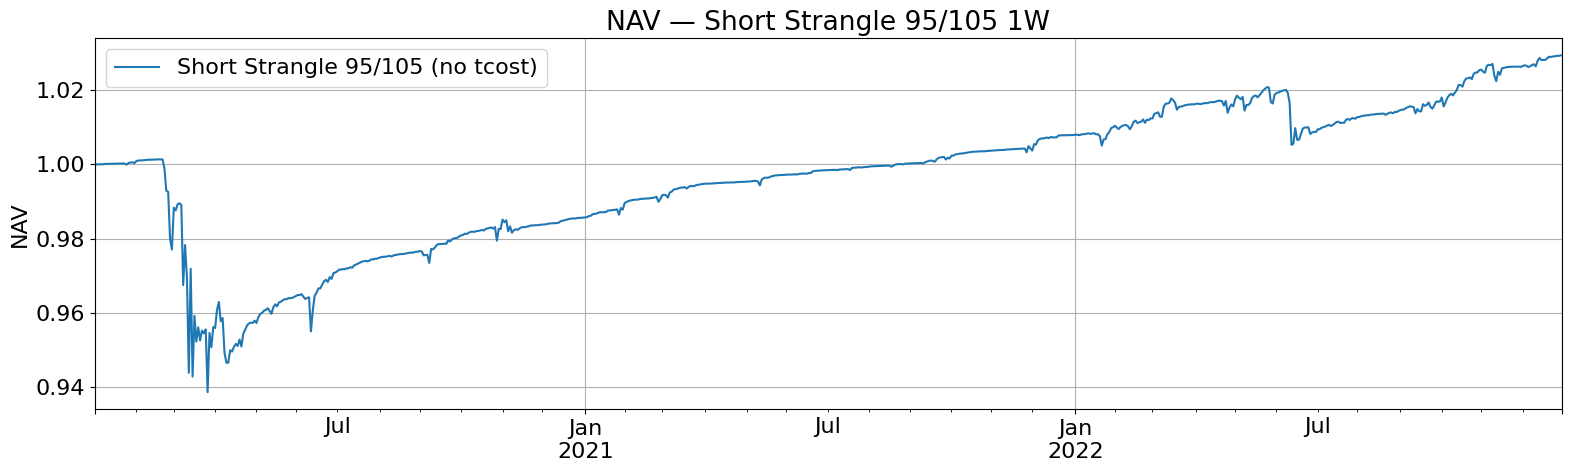

In [11]:
# ── NAV ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bt_base.nav["NAV"].plot(ax=ax, label="Short Strangle 95/105 (no tcost)", grid=True)
ax.set_title("NAV — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

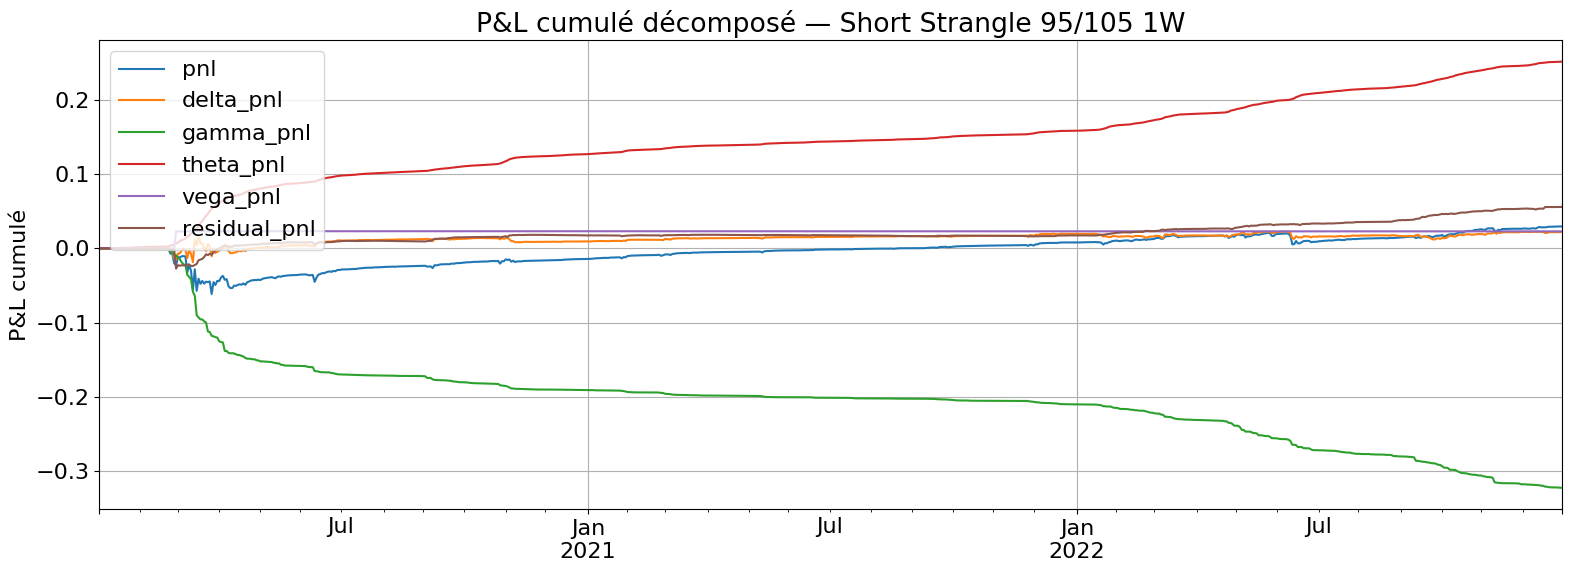

In [12]:
# ── Décomposition P&L cumulé ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.pnl.cumsum().plot(ax=ax, grid=True)
ax.set_title("P&L cumulé décomposé — Short Strangle 95/105 1W")
ax.set_ylabel("P&L cumulé")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

### 1.3 Impact des coûts de transaction

On compare trois modèles de coûts :
1. **Sans coût** — mid price utilisé partout
2. **Bid/Ask réel** — bid à l'entrée pour les shorts, ask à la sortie (et inversement pour les longs)
3. **Spread fixe 3%** — demi-spread de 3% du mid appliqué à chaque transaction

In [13]:
# Backtest avec bid/ask réel
bt_datatcost = BacktesterBidAskFromData(df_base).compute_backtest()

# Backtest avec spread fixe de 3%
bt_fixed3 = BacktesterFixedRelativeBidAsk(df_base).compute_backtest(
    tcost_args={"relative_half_spread": 0.03}
)

2026-03-20 11:28:59,709 | INFO | Loading option data for the backtest period.
2026-03-20 11:28:59,712 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:29:04,905 | INFO | Processing with {'ticker': ['SPY']}
2026-03-20 11:29:04,905 | INFO | Potentially add extra field with None
2026-03-20 11:29:19,087 | INFO | Forward filling option data for df
2026-03-20 11:29:20,154 | INFO | Applying bid-ask spread from data on transaction dates.
2026-03-20 11:29:20,237 | INFO | Computing period to period difference, for P&L calculations.
2026-03-20 11:29:20,247 | INFO | Append previous period greeks for P&L calculations.
2026-03-20 11:29:20,336 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:08<00:00, 90.14it/s]
2026-03-20 11:29:29,005 | INFO | Backtest computation completed.
2026-03-20 11:29:29,255 | INFO | Loading option data for the backtest period.
2026-03-20 11:29:29,258 | I

In [14]:
# ── Tableau comparatif ──────────────────────────────────────────────────────
results = []
for name, bt in [
    ("No transaction cost",       bt_base),
    ("Bid-Ask from data",          bt_datatcost),
    ("Fixed 3% half-spread",       bt_fixed3),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results.append({
        "Strategy": name,
        "Sharpe":   round(sharpe_ratio(rets), 2),
        "Max DD (%)": round(max_drawdown(rets) * 100, 1),
        "Calmar":   round(calmar_ratio(rets), 2),
    })

pd.DataFrame(results).set_index("Strategy")

,Sharpe,Max DD (%),Calmar
Strategy,,,
No transaction cost,0.25,-6.3,0.16
Bid-Ask from data,0.21,-6.4,0.14
Fixed 3% half-spread,0.15,-6.7,0.09


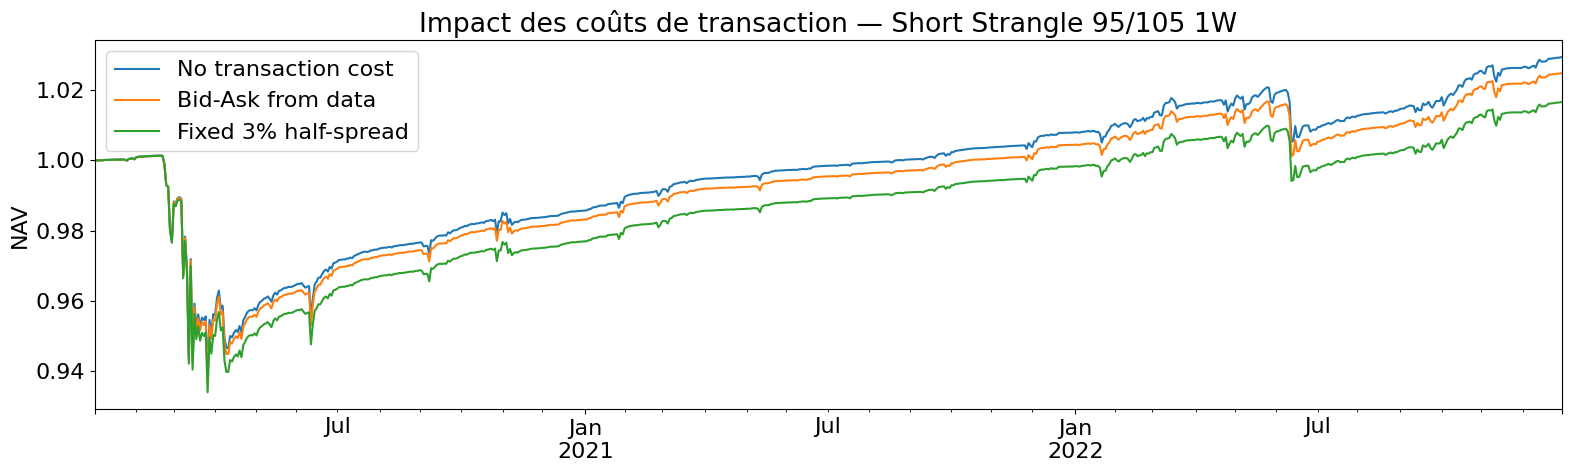

In [15]:
# ── Comparaison NAV ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
bt_base.nav["NAV"].plot(ax=ax,      label="No transaction cost", grid=True)
bt_datatcost.nav["NAV"].plot(ax=ax, label="Bid-Ask from data")
bt_fixed3.nav["NAV"].plot(ax=ax,    label="Fixed 3% half-spread")
ax.set_title("Impact des coûts de transaction — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

### 1.4 Delta Hedging

Le `DeltaHedgedOptionTrade` ajoute une jambe de couverture delta quotidienne.
Pour chaque groupe (date, ticker, entry_date), il calcule le delta net du portefeuille
et l'annule via une position spot dont l'expiration est fixée au maximum des
expirations des jambes d'options (correction vs l'implémentation originale).

L'effet attendu : réduction de la sensibilité directionnelle, isolement du P&L vega/gamma.

In [16]:
# Génération des positions avec delta hedging
df_dh = DeltaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
)

print(f"Positions avec delta hedge : {len(df_dh):,} lignes")
print(f"Jambes : {df_dh['leg_name'].unique().tolist()}")

2026-03-20 11:29:59,689 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-20 11:29:59,691 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:30:05,401 | INFO | Processing with {'ticker': 'SPY'}
2026-03-20 11:30:05,402 | INFO | Potentially add extra field with None
2026-03-20 11:30:14,615 | INFO | Preprocessing option data.
2026-03-20 11:30:14,617 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-20 11:30:16,338 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-20 11:30:17,989 | INFO | Converting 898 df_trades to daily time series
2026-03-20 11:30:23,935 | INFO | Forward filling option data for df
2026-03-20 11:30:24,707 

Positions avec delta hedge : 8,085 lignes
Jambes : ['DELTA_HEDGING', 'Short K=105% Call 1W', 'Short K=95% Put 1W']


In [17]:
# Backtest delta-hedgé
bt_dh = StrategyBacktester(df_dh).compute_backtest()

2026-03-20 11:30:35,694 | INFO | Loading option data for the backtest period.


2026-03-20 11:30:35,701 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:30:42,586 | INFO | Processing with {'ticker': ['SPY']}
2026-03-20 11:30:42,586 | INFO | Potentially add extra field with None
2026-03-20 11:30:58,974 | INFO | Forward filling option data for df
2026-03-20 11:31:00,294 | INFO | No transaction cost applied.
2026-03-20 11:31:00,369 | INFO | Computing period to period difference, for P&L calculations.
2026-03-20 11:31:00,378 | INFO | Append previous period greeks for P&L calculations.
2026-03-20 11:31:00,507 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:09<00:00, 86.50it/s] 
2026-03-20 11:31:09,540 | INFO | Backtest computation completed.


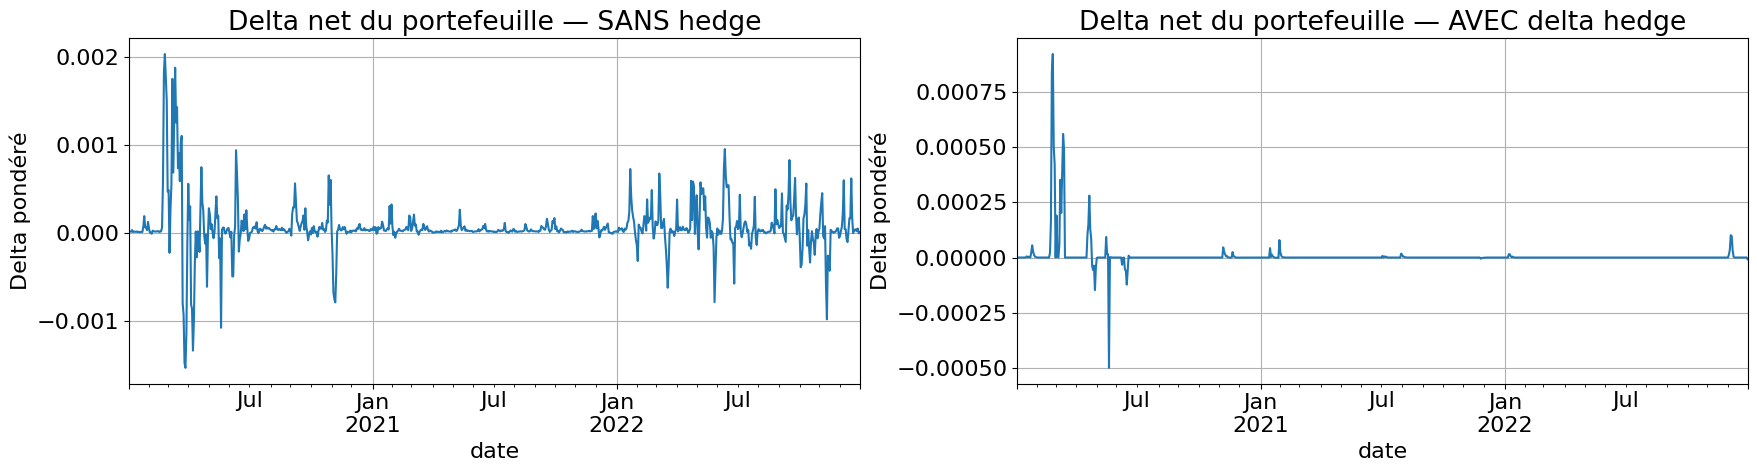

In [18]:
# ── Vérification : delta portefeuille avant/après hedge ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))

# Delta pondéré sans hedge
df_nd = bt_base.drifted_positions.copy()
df_nd["wgt_delta"] = df_nd["delta"] * df_nd["scaled_weight"]
df_nd.groupby("date")["wgt_delta"].sum().plot(ax=ax1, grid=True,
    title="Delta net du portefeuille — SANS hedge", ylabel="Delta pondéré")

# Delta pondéré avec hedge
df_dh_pos = bt_dh.drifted_positions.copy()
df_dh_pos["wgt_delta"] = df_dh_pos["delta"] * df_dh_pos["scaled_weight"]
df_dh_pos.groupby("date")["wgt_delta"].sum().plot(ax=ax2, grid=True,
    title="Delta net du portefeuille — AVEC delta hedge", ylabel="Delta pondéré")

plt.tight_layout()
plt.show()

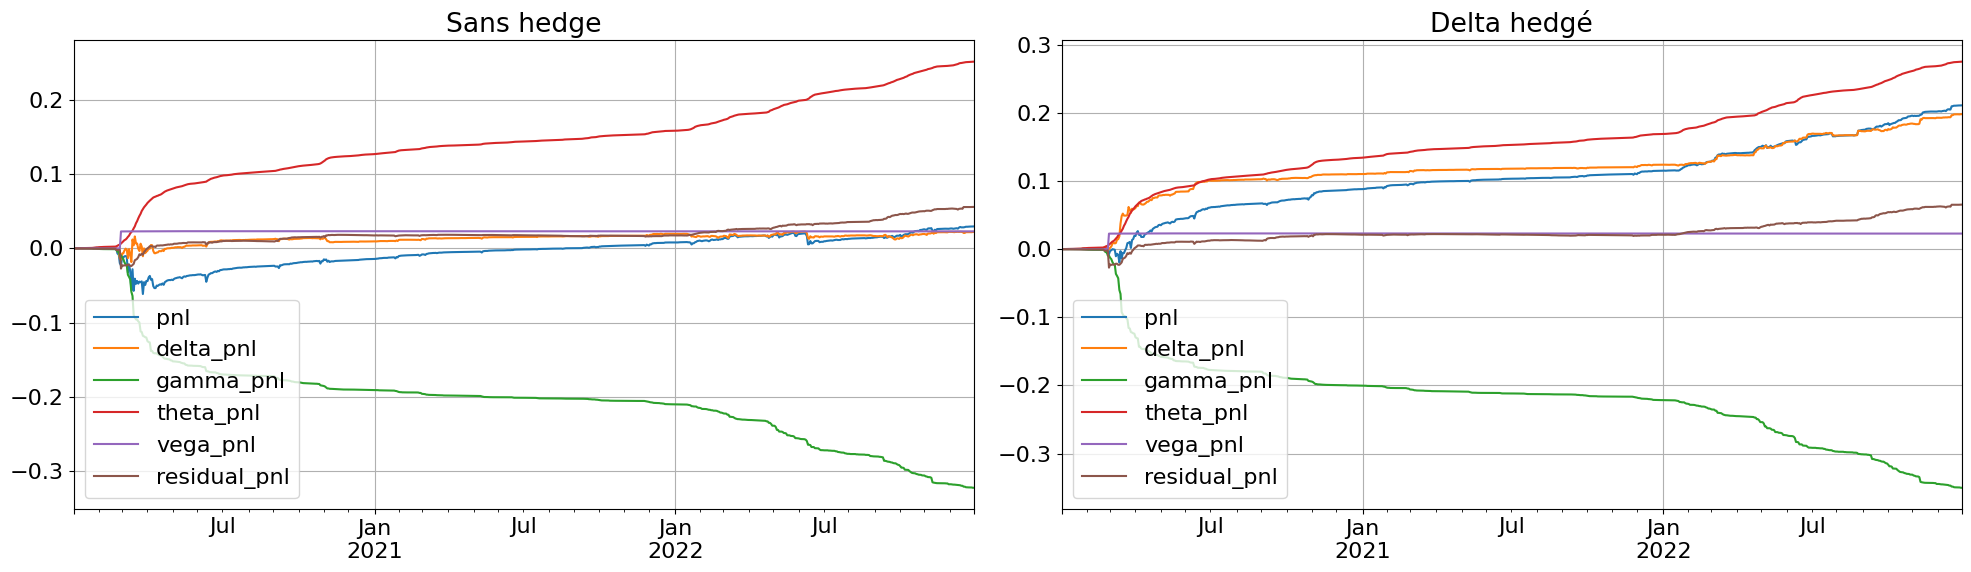

In [19]:
# ── Comparaison P&L décomposé : sans hedge vs delta-hedgé ───────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
bt_base.pnl.cumsum().plot(ax=ax1, title="Sans hedge", grid=True)
bt_dh.pnl.cumsum().plot(ax=ax2, title="Delta hedgé", grid=True)
plt.tight_layout()
plt.show()

### 1.5 Delta-Gamma Hedging

Le `DeltaGammaHedgedOptionTrade` ajoute d'abord une jambe d'option longue
pour couvrir le gamma (réduire la convexité du portefeuille), puis neutralise
le delta résultant via une couverture spot.

In [20]:
# La jambe de couverture gamma : long put 10D 5 jours
GAMMA_HEDGE_LEG = {
    "day_to_expiry_target": 5,
    "strike_target": -0.1,
    "strike_col": "delta",
    "call_or_put": "P",
    "weight": 0.2,
    "leg_name": "Long 10D Put 5d",
    "rebal_week_day": [2],
}

df_dgh = DeltaGammaHedgedOptionTrade.generate_trades(
    start_date=START,
    end_date=END,
    tickers=TICKER,
    legs=option_strategies.SHORT_1W_STRANGLE_95_105,
    cost_neutral=False,
    hedging_args={"hedging_leg": GAMMA_HEDGE_LEG},
)

print(f"Jambes présentes : {df_dgh['leg_name'].unique().tolist()}")

2026-03-20 11:31:11,329 | INFO | Loading option data from 2020-01-02 00:00:00 to 2022-12-30 00:00:00
2026-03-20 11:31:11,330 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:31:16,360 | INFO | Processing with {'ticker': 'SPY'}
2026-03-20 11:31:16,361 | INFO | Potentially add extra field with None
2026-03-20 11:31:24,398 | INFO | Preprocessing option data.
2026-03-20 11:31:24,400 | INFO | Selecting options for leg: Short K=95% Put 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 0.95, 'strike_col': 'moneyness', 'call_or_put': 'P'}
2026-03-20 11:31:26,045 | INFO | Selecting options for leg: Short K=105% Call 1W using the rules:
{'day_to_expiry_target': 7, 'strike_target': 1.05, 'strike_col': 'moneyness', 'call_or_put': 'C'}
2026-03-20 11:31:27,733 | INFO | Converting 898 df_trades to daily time series
2026-03-20 11:31:33,096 | INFO | Forward filling option data for df
2026-03-20 11:31:33,925 

Jambes présentes : ['DELTA_HEDGING', 'Short K=105% Call 1W', 'Short K=95% Put 1W', 'Long 10D Put 5d']


In [21]:
# Backtest delta-gamma hedgé
bt_dgh = StrategyBacktester(df_dgh).compute_backtest()

2026-03-20 11:32:05,016 | INFO | Loading option data for the backtest period.
2026-03-20 11:32:05,019 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None


2026-03-20 11:32:10,521 | INFO | Processing with {'ticker': ['SPY']}
2026-03-20 11:32:10,522 | INFO | Potentially add extra field with None
2026-03-20 11:32:27,061 | INFO | Forward filling option data for df
2026-03-20 11:32:28,465 | INFO | No transaction cost applied.
2026-03-20 11:32:28,550 | INFO | Computing period to period difference, for P&L calculations.
2026-03-20 11:32:28,564 | INFO | Append previous period greeks for P&L calculations.
2026-03-20 11:32:28,798 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:08<00:00, 88.23it/s]
2026-03-20 11:32:37,654 | INFO | Backtest computation completed.


In [22]:
# ── Tableau de synthèse Partie 1 ────────────────────────────────────────────
results_p1 = []
for name, bt in [
    ("Base (no hedge)",           bt_base),
    ("Delta hedged",               bt_dh),
    ("Delta-Gamma hedged",         bt_dgh),
    ("Base + data tcost",          bt_datatcost),
    ("Base + fixed 3% tcost",      bt_fixed3),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results_p1.append({
        "Strategy": name,
        "Sharpe":    round(sharpe_ratio(rets), 2),
        "Max DD (%)": round(max_drawdown(rets) * 100, 1),
        "Calmar":    round(calmar_ratio(rets), 2),
    })

pd.DataFrame(results_p1).set_index("Strategy")

,Sharpe,Max DD (%),Calmar
Strategy,,,
Base (no hedge),0.25,-6.3,0.16
Delta hedged,2.77,-2.1,2.94
Delta-Gamma hedged,3.19,-1.7,3.60
Base + data tcost,0.21,-6.4,0.14
Base + fixed 3% tcost,0.15,-6.7,0.09


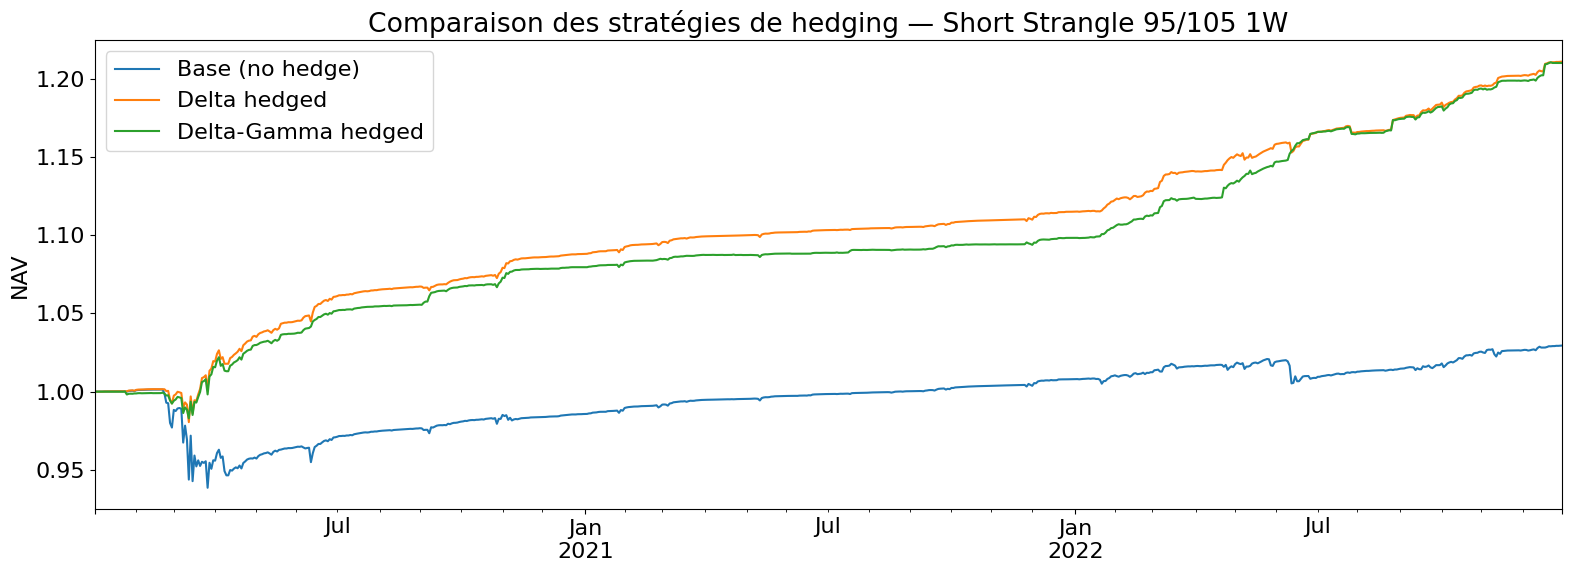

In [23]:
# ── Comparaison NAV ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.nav["NAV"].plot(ax=ax,  label="Base (no hedge)",        grid=True)
bt_dh.nav["NAV"].plot(ax=ax,    label="Delta hedged")
bt_dgh.nav["NAV"].plot(ax=ax,   label="Delta-Gamma hedged")
ax.set_title("Comparaison des stratégies de hedging — Short Strangle 95/105 1W")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

---
## Partie 2 — Nowcasting de la volatilité réalisée par UKF (dynamique de Heston)

### 2.1 Modèle en espace d'état et discrétisation

Le modèle de Heston est reformulé comme un **State Space Model (SSM)** :

**Équation d'état** (variance latente $v_t$) :
$$v_{t+1} = v_t + \kappa(\theta - v_t)\Delta t + \xi\sqrt{v_t}\sqrt{\Delta t}\,\varepsilon_t^{(2)}$$
$$\text{Bruit de processus : } Q_t = \xi^2 v_t \Delta t$$

**Équation d'observation** (log-return $r_t$ via formule d'Itô) :
$$r_t = \left(\mu - \frac{v_t}{2}\right)\Delta t + \sqrt{v_t \Delta t}\,\varepsilon_t^{(1)}$$
$$\text{Bruit de mesure : } R_t = v_t \Delta t$$

**Terme de corrélation** (spécifique à Heston, absent de filterpy standard) :
$$P_{xz} = \text{Cov}(v_{t+1}, r_t) = \rho \cdot \xi \cdot v_t \cdot \Delta t$$

Ce terme est injecté manuellement dans `HestonUKFCore.update()` avant le calcul
du gain de Kalman $K = P_{xz} \cdot S^{-1}$.

### 2.2 Chargement des données et préparation

In [24]:
# Chargement des données options et spot SPY
df_options = OptionLoader.load_data(START, END, process_kwargs={"ticker": TICKER})
df_spot = extract_spot_from_options(df_options)
df_rates = USRatesLoader.load_data(START, END)
df_options = compute_forward(df_options=df_options, df_rates=df_rates)

print(f"Options chargées : {len(df_options):,} lignes")
print(f"Dates : {df_options['date'].min().date()} → {df_options['date'].max().date()}")

2026-03-20 11:32:38,553 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-20 11:32:43,580 | INFO | Processing with {'ticker': 'SPY'}
2026-03-20 11:32:43,580 | INFO | Potentially add extra field with None
2026-03-20 11:32:51,550 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from ..//data/par-yield-curve-rates-2020-2023.csv with None
2026-03-20 11:32:51,637 | INFO | Processing with None
2026-03-20 11:32:51,638 | INFO | Potentially add extra field with None


Options chargées : 7,178,158 lignes
Dates : 2020-01-02 → 2022-12-30


Log-returns : 757 observations
Moyenne : 0.0003 | Std : 0.0159


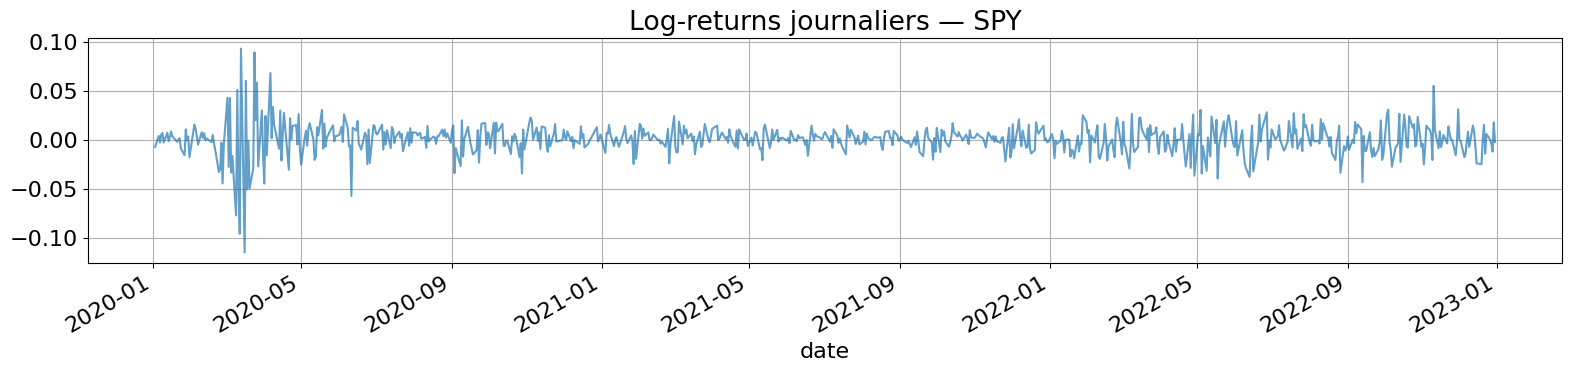

In [25]:
# ── Log-returns journaliers depuis le spot ───────────────────────────────────
# levels_to_returns calcule log(S_t / S_{t-1})
log_returns = levels_to_returns(df_spot.set_index("date")["spot"])
log_returns = log_returns.dropna()

print(f"Log-returns : {len(log_returns)} observations")
print(f"Moyenne : {log_returns.mean():.4f} | Std : {log_returns.std():.4f}")

fig, ax = plt.subplots(figsize=(16, 4))
log_returns.plot(ax=ax, grid=True, title="Log-returns journaliers — SPY", alpha=0.7)
plt.tight_layout()
plt.show()

In [26]:
# ── Volatilité implicite ATM (sigma_IV) ─────────────────────────────────────
# On sélectionne l'option ATM à la monnaie (moneyness ≈ 1) et maturité ~1 mois
from investment_lab.option_selection import select_options

df_atm = select_options(
    df_options,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)

# sigma_IV = série temporelle de la vol implicite ATM annualisée
sigma_iv = df_atm.set_index("date")["implied_volatility"]

print(f"sigma_IV : {len(sigma_iv)} dates")
print(f"Moyenne : {sigma_iv.mean():.2%} | Min : {sigma_iv.min():.2%} | Max : {sigma_iv.max():.2%}")

sigma_IV : 758 dates
Moyenne : 20.68% | Min : 9.81% | Max : 73.80%


### 2.3 Calibration MLE rolling des paramètres de Heston

Les paramètres $(\kappa, \theta, \xi, \rho, \mu)$ sont estimés par maximum de vraisemblance sur une **fenêtre glissante** de 252 jours.
À chaque date $t$, la calibration n'utilise que l'historique passé disponible avant la date de filtrage, ce qui maintient un cadre **out-of-sample**.


In [ ]:
# Calibration MLE rolling sur une fenêtre glissante de 252 jours
# Les paramètres affichés ci-dessous correspondent au dernier jeu calibré disponible.

ukf_model = HestonUKF(
    initial_params=HestonParams(kappa=2.0, theta=0.04, xi=0.3, rho=-0.7, mu=0.0),
    dt=1.0 / 252.0,
    cache_dir=".cache/heston_ukf",
)

ukf_model.fit(log_returns, window=252, use_cache=True, refit_every=5)

p = ukf_model.params
print("=== Dernier jeu de paramètres calibrés (rolling) ===")
print(f"  κ (kappa) = {p.kappa:.4f}  [vitesse mean-reversion]")
print(f"  θ (theta) = {p.theta:.4f}  [variance long terme → vol {np.sqrt(p.theta):.1%}]")
print(f"  ξ (xi)    = {p.xi:.4f}  [vol-of-vol]")
print(f"  ρ (rho)   = {p.rho:.4f}  [corrélation spot/variance]")
print(f"  μ (mu)    = {p.mu:.6f}  [drift]")
print(f"  Condition de Feller (2κθ > ξ²) : {p.feller_satisfied()}")
print(f"Première date calibrée : {ukf_model.rolling_params.index.min()}")
print(f"Dernière date calibrée : {ukf_model.rolling_params.index.max()}")


2026-03-20 11:34:49,248 | INFO | Fitting HestonUKF : n=757 observations, window=252.
2026-03-20 11:34:49,255 | INFO | Cache rolling chargé depuis .cache/heston_ukf/rolling_bff7497f09a53038c3989154f25f52192a66d323ffcd005be28a5382b533b318.pkl (60 lignes).
2026-03-20 11:34:49,264 | INFO | Reprise de la calibration rolling après 2021-04-05 00:00:00.


### 2.4 Diagnostics de calibration rolling

On inspecte ici les diagnostics de la calibration rolling :
- dates exactes de la fenêtre utilisée pour chaque fit ;
- convergence de l'optimiseur ;
- amélioration de la log-vraisemblance ;
- stabilité des paramètres dans le temps.

Point méthodologique clé : à la date de calibration $t$, la log-vraisemblance est calculée sur la fenêtre **passée** `[t-window, t)`.


In [ ]:
# ── Diagnostics de calibration rolling ────────────────────────────────────
fit_diag = ukf_model.fit_diagnostics
rolling_params = ukf_model.rolling_params

# Vérification explicite : le fit daté t utilise seulement la fenêtre passée [t-window, t)
assert (fit_diag.index > pd.to_datetime(fit_diag["window_end"])).all(), "Une calibration semble utiliser la date courante ou future."

fit_diag_summary = pd.DataFrame({
    "metric": [
        "n_fits",
        "optimizer_success_rate",
        "median_loglik_improvement",
        "min_loglik_improvement",
        "share_feller_violation",
        "avg_nfev",
    ],
    "value": [
        len(fit_diag),
        fit_diag["optimizer_success"].mean(),
        fit_diag["loglik_improvement"].median(),
        fit_diag["loglik_improvement"].min(),
        (fit_diag["feller_violation"] > 0).mean(),
        fit_diag["nfev"].mean(),
    ],
}).set_index("metric")
display(fit_diag_summary)

display(fit_diag[["window_start", "window_end", "window_size", "optimizer_success", "start_loglik", "final_loglik", "loglik_improvement"]].head(10))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fit_diag["final_loglik"].plot(ax=axes[0], color="steelblue", grid=True, label="Final log-likelihood")
fit_diag["start_loglik"].plot(ax=axes[0], color="gray", alpha=0.6, label="Start log-likelihood")
axes[0].set_title("Calibration rolling — log-vraisemblance par date de fit")
axes[0].legend()

fit_diag["loglik_improvement"].plot(ax=axes[1], color="darkorange", grid=True, label="Gain de log-likelihood")
axes[1].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[1].set_title("Calibration rolling — amélioration de log-vraisemblance")
axes[1].legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 2, figsize=(16, 10), sharex=True)
for ax, col in zip(axes.flatten(), ["kappa", "theta", "xi", "rho", "mu"]):
    rolling_params[col].plot(ax=ax, grid=True, title=col)
axes[-1, -1].axis("off")
plt.tight_layout()
plt.show()


### 2.5 Filtrage UKF — estimation de $\hat{v}_t$

Le filtre propage 3 sigma-points (Merwe α=1e-3, β=2, κ=0) à travers la dynamique
de Heston à chaque pas de temps. La correction $\rho \cdot \xi \cdot v_t \cdot \Delta t$
est injectée dans $P_{xz}$ avant le calcul du gain de Kalman.

On utilise ici `filter_with_diagnostics()` afin de conserver les innovations, la variance d'innovation et le gain de Kalman pour l'analyse.


In [28]:
# Filtrage UKF avec diagnostics complets
filter_diag = ukf_model.filter_with_diagnostics(log_returns)
v_hat = filter_diag["v_hat"]
sigma_hat = filter_diag["sigma_hat"]

print(f"v_hat estimé — Moyenne : {v_hat.mean():.4f} | Std : {v_hat.std():.4f}")
print(f"sigma_hat estimé — Moyenne : {sigma_hat.mean():.2%}")
print(f"Innovation standardisée — Moyenne : {filter_diag['std_innovation'].mean():.3f} | Std : {filter_diag['std_innovation'].std():.3f}")
print(f"Kalman gain — Moyenne : {filter_diag['kalman_gain'].mean():.4f}")


RuntimeError: Appeler fit() avant filter().

### 2.6 Diagnostics du filtre

On vérifie que les innovations standardisées restent raisonnablement centrées et que le gain de Kalman ne présente pas de comportement explosif.


In [ ]:
# ── Diagnostics du filtre UKF ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 9))

filter_diag["std_innovation"].plot(ax=axes[0, 0], color="steelblue", grid=True)
axes[0, 0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0, 0].set_title("Innovation standardisée")

filter_diag["std_innovation"].hist(ax=axes[0, 1], bins=50, color="steelblue", alpha=0.8)
axes[0, 1].set_title("Distribution des innovations standardisées")

filter_diag["kalman_gain"].plot(ax=axes[1, 0], color="darkorange", grid=True)
axes[1, 0].set_title("Gain de Kalman")

filter_diag[["innovation_var"]].plot(ax=axes[1, 1], color="seagreen", grid=True, legend=False)
axes[1, 1].set_title("Variance d'innovation")

plt.tight_layout()
plt.show()


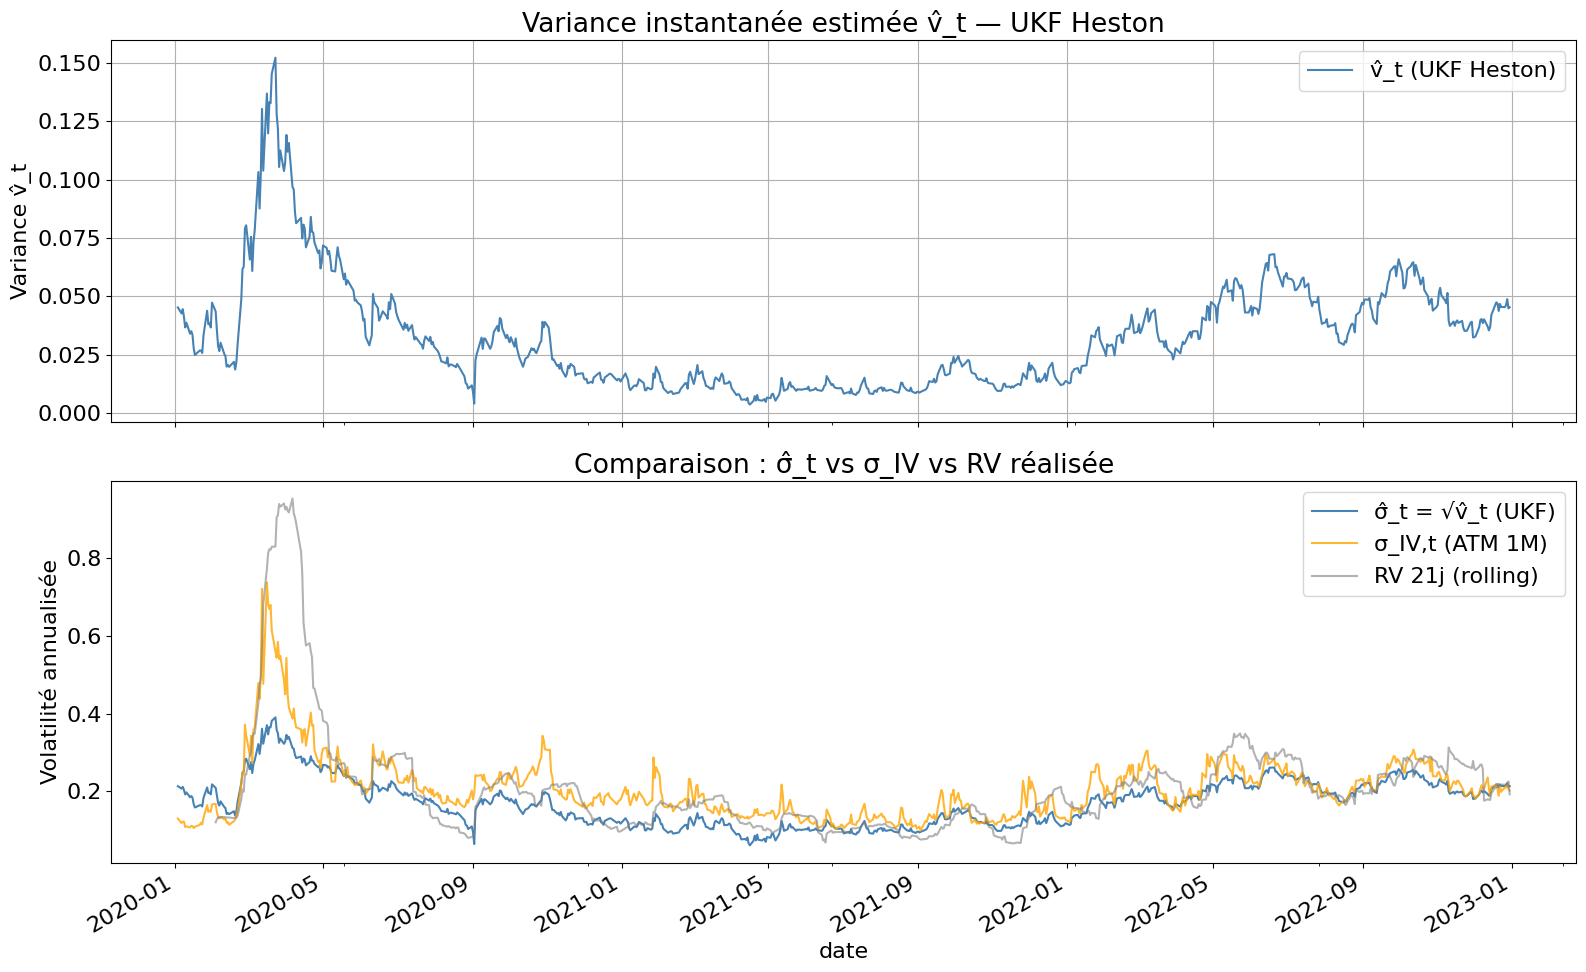

In [38]:
# ── Visualisation : v_hat et sigma_hat vs vol réalisée ───────────────────────
# Volatilité réalisée comme référence
rv_21d = rolling_realized_volatility(log_returns, window=21, volatility_type="std")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Variance filtrée
v_hat.plot(ax=ax1, label="v̂_t (UKF Heston)", color="steelblue", grid=True)
ax1.set_title("Variance instantanée estimée v̂_t — UKF Heston")
ax1.set_ylabel("Variance v̂_t")
ax1.legend()

# Volatilité estimée vs vol implicite vs vol réalisée
sigma_hat.plot(ax=ax2, label="σ̂_t = √v̂_t (UKF)", color="steelblue", grid=True)
sigma_iv.reindex(sigma_hat.index).plot(ax=ax2, label="σ_IV,t (ATM 1M)", color="orange", alpha=0.8)
rv_21d.reindex(sigma_hat.index).plot(ax=ax2, label="RV 21j (rolling)", color="gray", alpha=0.6)
ax2.set_title("Comparaison : σ̂_t vs σ_IV vs RV réalisée")
ax2.set_ylabel("Volatilité annualisée")
ax2.legend()

plt.tight_layout()
plt.show()

### 2.7 Spread IV-RV  $s_t = \sigma_{IV,t} - \hat{\sigma}_t$

Le spread mesure la **prime de risque de volatilité** estimée :
- $s_t > 0$ → IV chère par rapport à la RV estimée → carry positif → **short vol profitable**
- $s_t < 0$ → IV bon marché → RV > IV → réduire/fermer la position

Spread s_t — Moyenne : 3.67% | Std : 4.63%
% jours s_t > 0 (IV chère) : 87.2%


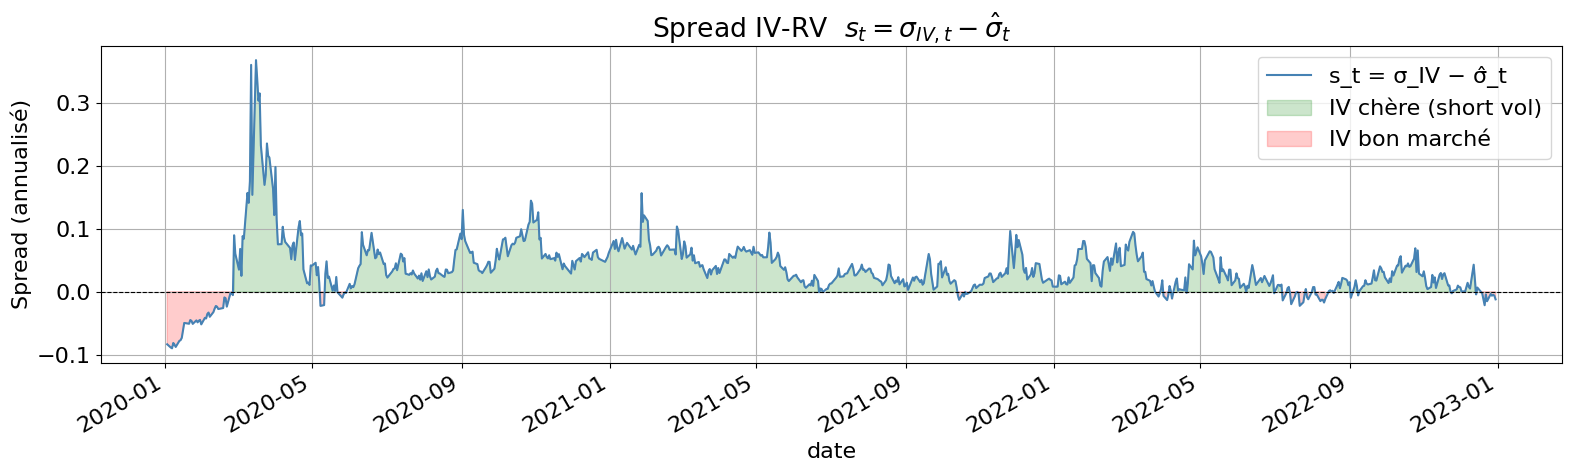

In [39]:
# Calcul du spread s_t = sigma_IV - sigma_hat
spread = ukf_model.implied_realized_spread(sigma_iv)

print(f"Spread s_t — Moyenne : {spread.mean():.2%} | Std : {spread.std():.2%}")
print(f"% jours s_t > 0 (IV chère) : {(spread > 0).mean():.1%}")

fig, ax = plt.subplots(figsize=(16, 5))
spread.plot(ax=ax, label="s_t = σ_IV − σ̂_t", color="steelblue", grid=True)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(spread.index, spread, 0,
                where=(spread > 0), alpha=0.2, color="green",  label="IV chère (short vol)")
ax.fill_between(spread.index, spread, 0,
                where=(spread < 0), alpha=0.2, color="red",    label="IV bon marché")
ax.set_title("Spread IV-RV  $s_t = \sigma_{IV,t} - \hat{\sigma}_t$")
ax.set_ylabel("Spread (annualisé)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.8 Signal de timing et allocation dynamique

On normalise $s_t$ en un signal d'allocation $f(s_t) \in [-\text{max\_leverage}, +\text{max\_leverage}]$
puis on l'applique aux poids de la stratégie de base :
$$w_t = w_{\text{base}} \times f(s_t)$$

Trois modes de normalisation sont disponibles :
- **linear** : $f(s_t) = \text{clip}(s_t / \sigma_{s}, \pm L)$ — proportionnel au spread normalisé
- **rank** : percentile roulant recentré — robuste aux outliers  
- **threshold** : signal binaire ±1 au-delà de bandes ±seuil

Convention de backtest retenue pour éviter tout **look-ahead bias** :
- le spread $s_t$ et le signal $f(s_t)$ sont calculés avec l'information disponible à la clôture de la date $t$ ;
- ce signal n'est **pas** appliqué à la position du même jour ;
- l'exécution est décalée d'**un jour ouvré** : le poids utilisé à la date $t+1$ dépend du signal observé à la date $t$.

Autrement dit, dans le backtest, la décision exécutable au jour $t$ ne dépend jamais d'une information future.


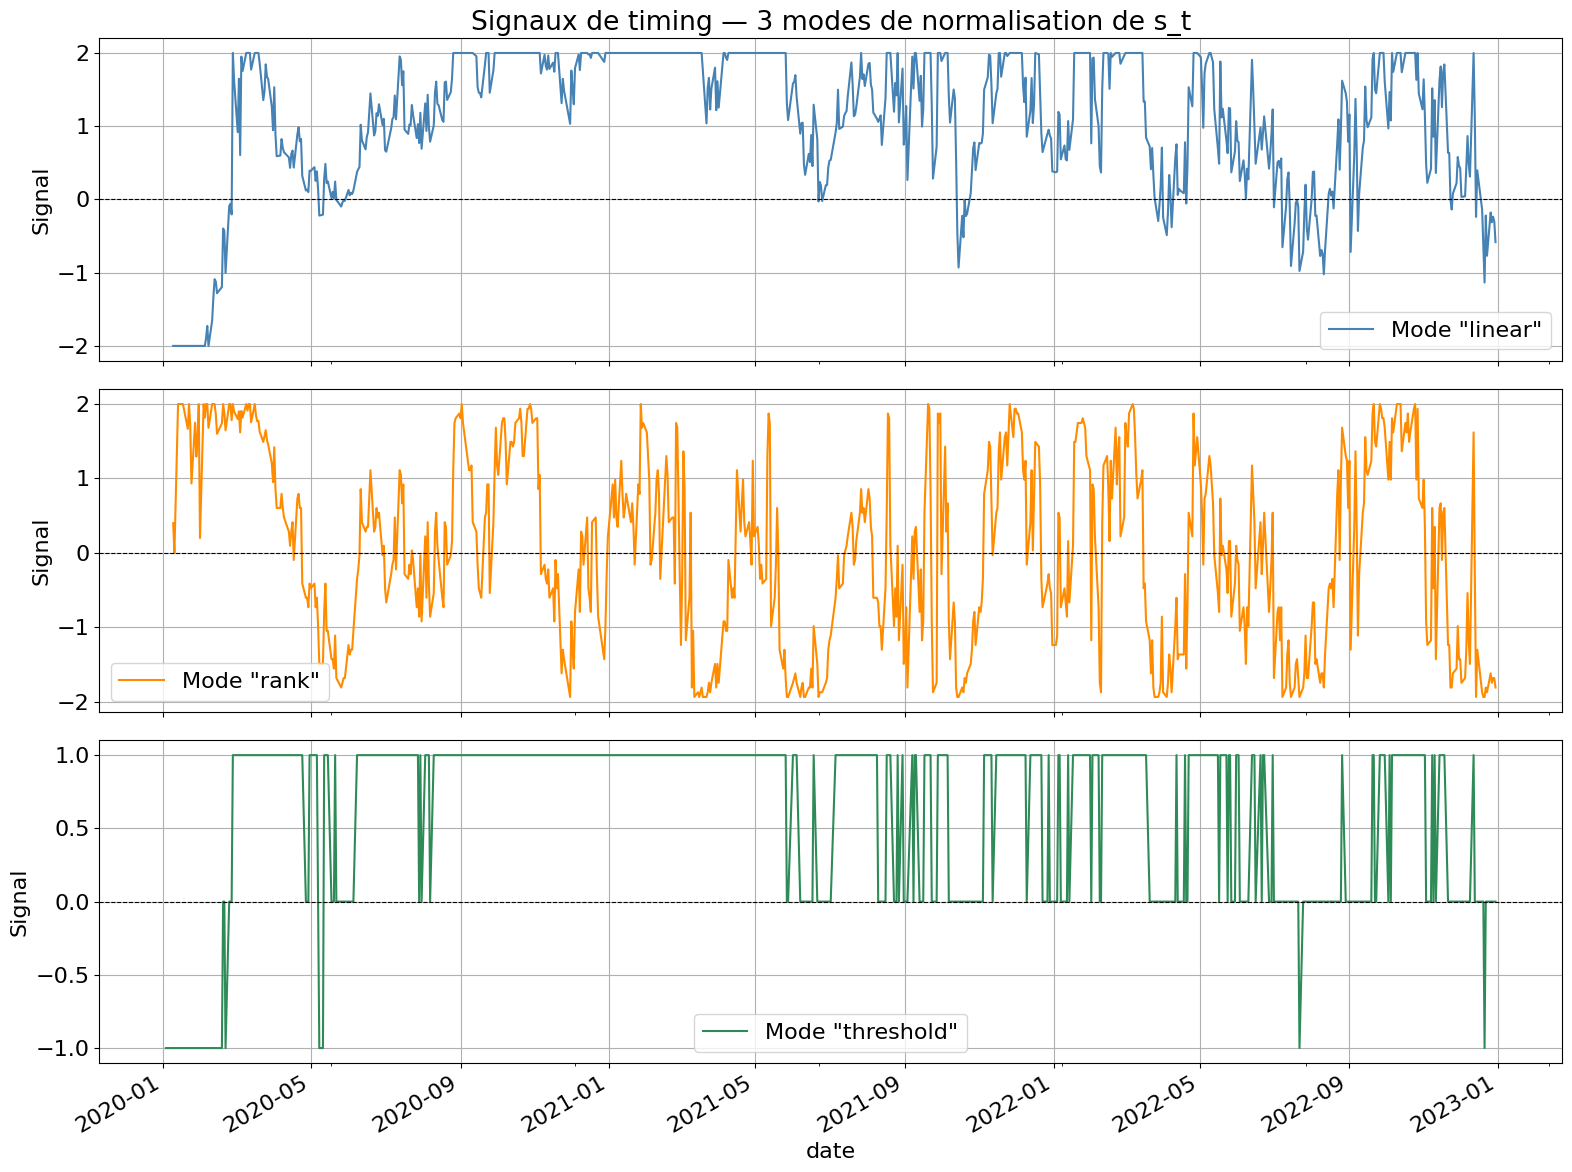

In [40]:
# ── Visualisation des 3 modes de signal ─────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for ax, mode, color in zip(axes, ["linear", "rank", "threshold"], ["steelblue", "darkorange", "seagreen"]):
    timer = VolatilityTiming(scaling=mode, lookback=63, max_leverage=2.0, threshold=0.02)
    sig = timer.compute_signal(spread)
    sig.plot(ax=ax, color=color, grid=True, label=f'Mode "{mode}"')
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_ylabel("Signal")
    ax.legend()

axes[0].set_title("Signaux de timing — 3 modes de normalisation de s_t")
plt.tight_layout()
plt.show()

### 2.9 Backtest avec timing dynamique

On compare le backtest de la stratégie de base avec les versions timées par l'UKF.
On utilise `build_timing_positions()` qui enchaîne les 5 étapes du pipeline de manière reproductible.

Important : cette cellule relance un pipeline complet UKF `fit -> filter -> spread -> signal -> timing`.
Le but est d'obtenir des positions timées de bout en bout dans un cadre homogène de backtest, même si certaines briques ont déjà été analysées séparément plus haut.

Ici, on rend le paramètre `signal_lag_bdays=1` explicite pour documenter la convention d'exécution :
- signal calculé à la date $t$ ;
- poids effectivement appliqué à la date $t+1$ ;
- aucune utilisation d'information future dans la construction des positions.


In [43]:
# ── Positions avec timing UKF (mode linear) ─────────────────────────────────
signal_lag_bdays = 1  # Exécution à t+1 pour éviter tout look-ahead bias

df_timed_linear, spread_l, signal_linear = build_timing_positions(
    df_positions      = df_base,
    log_returns       = log_returns,
    sigma_iv          = sigma_iv,
    fit_window        = 252,
    scaling           = "linear",
    lookback          = 63,
    max_leverage      = 2.0,
    signal_lag_bdays  = signal_lag_bdays,
)

# ── Positions avec timing UKF (mode threshold) ───────────────────────────────
df_timed_thresh, spread_t, signal_thresh = build_timing_positions(
    df_positions      = df_base,
    log_returns       = log_returns,
    sigma_iv          = sigma_iv,
    fit_window        = 252,
    scaling           = "threshold",
    lookback          = 63,
    max_leverage      = 2.0,
    threshold         = 0.02,
    signal_lag_bdays  = signal_lag_bdays,
)

print("Positions timées générées avec un lag d'exécution de", signal_lag_bdays, "jour ouvré.")


2026-03-16 11:55:53,939 | INFO | Démarrage du pipeline HestonUKF timing.
2026-03-16 11:55:53,940 | INFO | Fitting HestonUKF : n=757 observations, window=252.
2026-03-16 11:56:10,784 | INFO | MLE convergé. kappa=1.907 theta=0.0265 xi=0.318 rho=-0.765 mu=0.0434
2026-03-16 11:56:10,891 | INFO | Volatility timing appliqué à 5390 lignes.
2026-03-16 11:56:10,893 | INFO | Démarrage du pipeline HestonUKF timing.
2026-03-16 11:56:10,893 | INFO | Fitting HestonUKF : n=757 observations, window=252.
2026-03-16 11:56:27,392 | INFO | MLE convergé. kappa=1.907 theta=0.0265 xi=0.318 rho=-0.765 mu=0.0434
2026-03-16 11:56:27,503 | INFO | Volatility timing appliqué à 5390 lignes.


Positions timées générées.


### 2.10 Vérification explicite de l'absence de look-ahead bias

On contrôle ci-dessous que le signal calculé à une date donnée est bien exécuté au **jour ouvré suivant**.
Cette vérification permet de documenter clairement l'alignement entre :
- la date du signal ;
- la date de la position effectivement modifiée dans le backtest.


In [ ]:
# ── Vérification de l'alignement signal -> exécution ───────────────────────
signal_exec_linear = signal_linear.copy()
signal_exec_linear.index = signal_exec_linear.index + pd.offsets.BDay(signal_lag_bdays)

df_signal_check = pd.DataFrame({
    "signal_date": signal_linear.index,
    "execution_date": signal_exec_linear.index,
    "signal_value": signal_linear.values,
})

print("Premières dates signal -> exécution :")
display(df_signal_check.head(10))

first_timed_date = df_timed_linear.loc[df_timed_linear["weight"] != df_base["weight"], "date"].min()
first_signal_date = signal_linear.index.min()
expected_first_exec = first_signal_date + pd.offsets.BDay(signal_lag_bdays)

print(f"Première date de signal disponible      : {first_signal_date}")
print(f"Première date d'exécution attendue      : {expected_first_exec}")
print(f"Première date où le poids change vraiment: {first_timed_date}")

assert first_timed_date >= expected_first_exec, "Le backtest semble utiliser le signal trop tôt."
print("Vérification OK : le timing est appliqué avec un décalage compatible avec une exécution sans look-ahead.")


In [44]:
# Backtest des stratégies timées
bt_timed_linear = StrategyBacktester(df_timed_linear).compute_backtest()
bt_timed_thresh = StrategyBacktester(df_timed_thresh).compute_backtest()

2026-03-16 11:56:30,725 | INFO | Loading option data for the backtest period.
2026-03-16 11:56:30,731 | INFO | Reading between 2020-01-03 00:00:00 2022-12-30 00:00:00 from ..//data/optiondb_2016_2023.parquet with None
2026-03-16 11:56:39,151 | INFO | Processing with {'ticker': ['SPY']}
2026-03-16 11:56:39,152 | INFO | Potentially add extra field with None
2026-03-16 11:56:53,871 | INFO | Forward filling option data for df
2026-03-16 11:56:54,783 | INFO | No transaction cost applied.
2026-03-16 11:56:54,856 | INFO | Computing period to period difference, for P&L calculations.
2026-03-16 11:56:54,866 | INFO | Append previous period greeks for P&L calculations.
2026-03-16 11:56:54,993 | INFO | Starting backtest computation over 781 unique dates.
100%|██████████| 781/781 [00:08<00:00, 93.61it/s] 
2026-03-16 11:57:03,352 | INFO | Backtest computation completed.
2026-03-16 11:57:03,997 | INFO | Deleting StrategyBacktest instance.
2026-03-16 11:57:04,232 | INFO | Loading option data for the b

In [45]:
# ── Tableau de synthèse complet ──────────────────────────────────────────────
results_final = []
for name, bt in [
    ("Base (no hedge, no timing)",         bt_base),
    ("Delta hedged",                        bt_dh),
    ("UKF Timing — linear (no hedge)",     bt_timed_linear),
    ("UKF Timing — threshold (no hedge)",  bt_timed_thresh),
]:
    rets = bt.nav["NAV"].pct_change().dropna()
    results_final.append({
        "Strategy":    name,
        "Sharpe":      round(sharpe_ratio(rets), 2),
        "Max DD (%)":  round(max_drawdown(rets) * 100, 1),
        "Calmar":      round(calmar_ratio(rets), 2),
    })

pd.DataFrame(results_final).set_index("Strategy")

,Sharpe,Max DD (%),Calmar
Strategy,,,
"Base (no hedge, no timing)",0.25,-6.3,0.16
Delta hedged,2.77,-2.1,2.94
UKF Timing — linear (no hedge),-0.62,-15.0,-0.33
UKF Timing — threshold (no hedge),-0.47,-6.1,-0.32


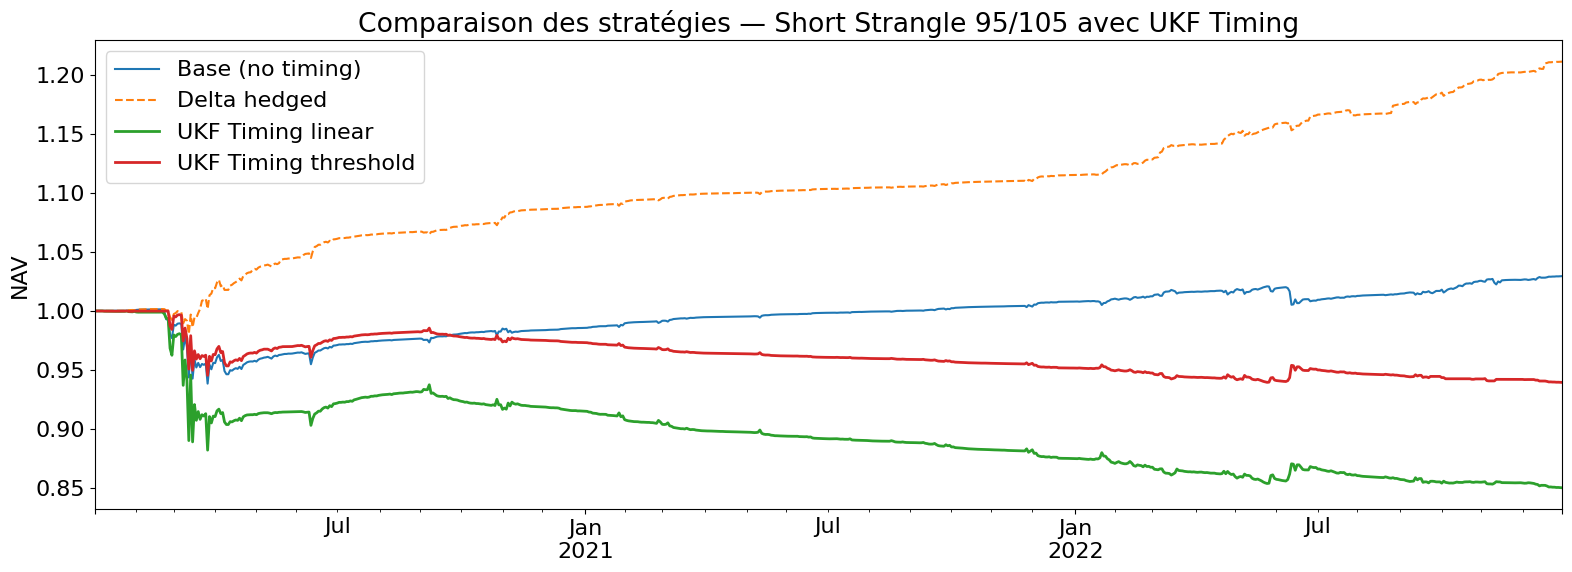

In [46]:
# ── Comparaison NAV finale ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
bt_base.nav["NAV"].plot(ax=ax,          label="Base (no timing)",       grid=True, linewidth=1.5)
bt_dh.nav["NAV"].plot(ax=ax,            label="Delta hedged",           linestyle="--")
bt_timed_linear.nav["NAV"].plot(ax=ax,  label="UKF Timing linear",      linewidth=2)
bt_timed_thresh.nav["NAV"].plot(ax=ax,  label="UKF Timing threshold",   linewidth=2)
ax.set_title("Comparaison des stratégies — Short Strangle 95/105 avec UKF Timing")
ax.set_ylabel("NAV")
ax.legend()
plt.tight_layout()
plt.show()

### 2.11 Analyse du signal UKF en période de stress

On examine ici le comportement conjoint de la NAV, du spread IV-RV et du signal de timing pour vérifier que le modèle réduit bien l'exposition pendant les épisodes de stress de volatilité.


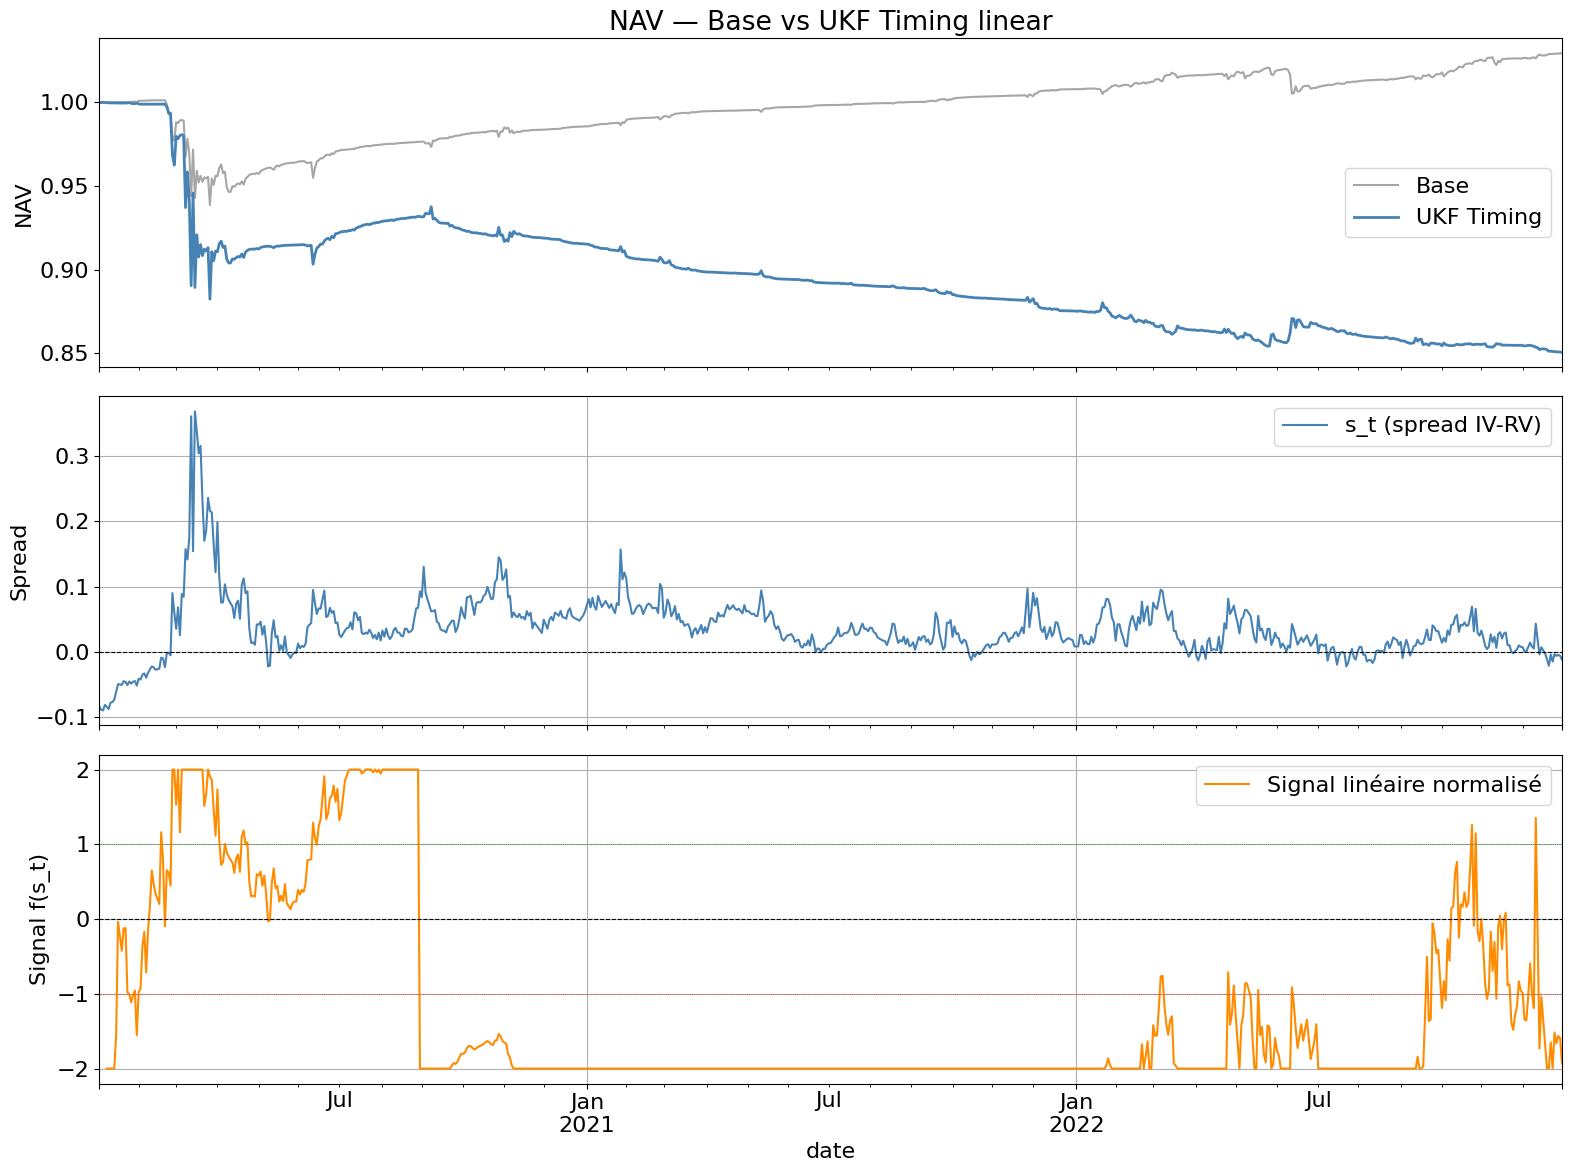

In [47]:
# ── Signal UKF vs distribution des returns ───────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

# NAV timée vs base
bt_base.nav["NAV"].plot(ax=ax1, label="Base", grid=True, color="gray", alpha=0.7)
bt_timed_linear.nav["NAV"].plot(ax=ax1, label="UKF Timing", color="steelblue", linewidth=2)
ax1.set_ylabel("NAV")
ax1.legend()
ax1.set_title("NAV — Base vs UKF Timing linear")

# Spread et signal du pipeline effectivement backtesté
spread_l.plot(ax=ax2, color="steelblue", label="s_t (spread IV-RV)", grid=True)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Spread")
ax2.legend()

# Signal normalisé
signal_linear.plot(ax=ax3, color="darkorange", label="Signal linéaire normalisé", grid=True)
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.axhline(1, color="green", linewidth=0.5, linestyle=":")
ax3.axhline(-1, color="red", linewidth=0.5, linestyle=":")
ax3.set_ylabel("Signal f(s_t)")
ax3.legend()

plt.tight_layout()
plt.show()


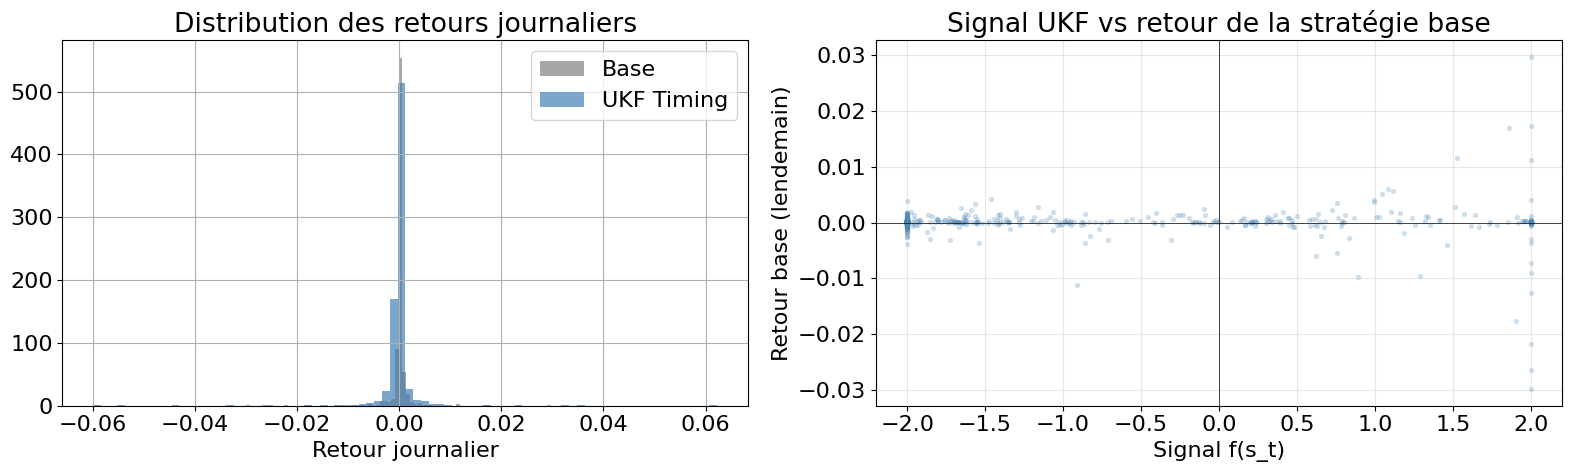

In [48]:
# ── Distribution des retours : base vs timée ────────────────────────────────
rets_base_   = bt_base.nav["NAV"].pct_change().dropna()
rets_timed_  = bt_timed_linear.nav["NAV"].pct_change().dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

rets_base_.hist(bins=80, ax=ax1, alpha=0.7, color="gray", label="Base")
rets_timed_.hist(bins=80, ax=ax1, alpha=0.7, color="steelblue", label="UKF Timing")
ax1.set_title("Distribution des retours journaliers")
ax1.legend()
ax1.set_xlabel("Retour journalier")

# Scatter : on utilise le signal effectivement exécutable (décalé à t+1)
common_idx = rets_base_.index.intersection(signal_exec_linear.index)
ax2.scatter(
    signal_exec_linear.loc[common_idx],
    rets_base_.loc[common_idx],
    alpha=0.2, s=8, color="steelblue"
)
ax2.axhline(0, color="black", linewidth=0.5)
ax2.axvline(0, color="black", linewidth=0.5)
ax2.set_xlabel("Signal exécutable f(s_t)")
ax2.set_ylabel("Retour base du jour d'exécution")
ax2.set_title("Signal exécutable UKF vs retour de la stratégie base")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 2.12 Validation économétrique du signal

On cherche ici à vérifier que le signal UKF contient un contenu informatif au-delà des seuls graphes de NAV.
On regarde trois choses :
- corrélation entre signal exécutable, spread et retours de la stratégie ;
- régression linéaire simple des retours sur le signal ;
- comportement moyen des retours par quantile de signal.


In [ ]:
# ── Validation économétrique du signal UKF ───────────────────────────────
import statsmodels.api as sm

df_econo = pd.concat([
    spread_l.rename("spread"),
    signal_exec_linear.rename("signal_exec"),
    bt_base.nav["NAV"].pct_change().rename("base_ret"),
    bt_timed_linear.nav["NAV"].pct_change().rename("timed_ret"),
], axis=1).dropna()

display(df_econo[["spread", "signal_exec", "base_ret", "timed_ret"]].corr())

X_signal = sm.add_constant(df_econo["signal_exec"])
model_signal = sm.OLS(df_econo["base_ret"], X_signal).fit()

X_spread = sm.add_constant(df_econo["spread"])
model_spread = sm.OLS(df_econo["base_ret"], X_spread).fit()

reg_summary = pd.DataFrame({
    "model": ["base_ret ~ signal_exec", "base_ret ~ spread"],
    "beta": [model_signal.params.iloc[1], model_spread.params.iloc[1]],
    "t_stat": [model_signal.tvalues.iloc[1], model_spread.tvalues.iloc[1]],
    "p_value": [model_signal.pvalues.iloc[1], model_spread.pvalues.iloc[1]],
    "r_squared": [model_signal.rsquared, model_spread.rsquared],
})
display(reg_summary)

df_econo["signal_bucket"] = pd.qcut(df_econo["signal_exec"], q=5, duplicates="drop")
bucket_stats = df_econo.groupby("signal_bucket")[ ["base_ret", "timed_ret", "signal_exec"] ].mean()
display(bucket_stats)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].scatter(df_econo["signal_exec"], df_econo["base_ret"], alpha=0.25, s=10, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Signal exécutable vs retour base")
axes[0].set_xlabel("signal_exec")
axes[0].set_ylabel("base_ret")
axes[0].grid(True, alpha=0.3)

bucket_stats[["base_ret", "timed_ret"]].plot(kind="bar", ax=axes[1], grid=True)
axes[1].set_title("Retour moyen par quantile de signal")
axes[1].set_ylabel("Retour moyen")
plt.tight_layout()
plt.show()


### 2.13 Vérification out-of-sample et alignement des dates

On vérifie ici que toute la chaîne de construction du signal reste **out-of-sample** :
- calibration des paramètres sur fenêtre glissante passée ;
- filtrage UKF seulement après disponibilité de la fenêtre de calibration ;
- construction du spread puis du signal sur les dates effectivement observées ;
- exécution des poids avec un décalage d'un jour ouvré.

Le but est de contrôler l'alignement de `log_returns`, `rolling_params`, `sigma_hat`, `spread`, `signal` et `positions`.


In [ ]:
# ── Vérification out-of-sample de bout en bout ────────────────────────────
oos_summary = pd.DataFrame([
    {"object": "log_returns",        "start": log_returns.dropna().index.min(),             "end": log_returns.dropna().index.max(),             "n_obs": log_returns.dropna().shape[0]},
    {"object": "rolling_params",     "start": ukf_model.rolling_params.index.min(),        "end": ukf_model.rolling_params.index.max(),        "n_obs": ukf_model.rolling_params.shape[0]},
    {"object": "v_hat",              "start": v_hat.dropna().index.min(),                   "end": v_hat.dropna().index.max(),                   "n_obs": v_hat.dropna().shape[0]},
    {"object": "sigma_hat",          "start": sigma_hat.dropna().index.min(),               "end": sigma_hat.dropna().index.max(),               "n_obs": sigma_hat.dropna().shape[0]},
    {"object": "sigma_iv",           "start": sigma_iv.dropna().index.min(),                "end": sigma_iv.dropna().index.max(),                "n_obs": sigma_iv.dropna().shape[0]},
    {"object": "spread_linear",      "start": spread_l.dropna().index.min(),                "end": spread_l.dropna().index.max(),                "n_obs": spread_l.dropna().shape[0]},
    {"object": "signal_linear",      "start": signal_linear.dropna().index.min(),           "end": signal_linear.dropna().index.max(),           "n_obs": signal_linear.dropna().shape[0]},
    {"object": "signal_exec_linear", "start": signal_exec_linear.dropna().index.min(),      "end": signal_exec_linear.dropna().index.max(),      "n_obs": signal_exec_linear.dropna().shape[0]},
    {"object": "df_base dates",      "start": df_base["date"].min(),                         "end": df_base["date"].max(),                         "n_obs": df_base["date"].nunique()},
    {"object": "df_timed dates",     "start": df_timed_linear["date"].min(),                 "end": df_timed_linear["date"].max(),                 "n_obs": df_timed_linear["date"].nunique()},
    {"object": "bt_timed_linear NAV", "start": bt_timed_linear.nav.index.min(),               "end": bt_timed_linear.nav.index.max(),               "n_obs": bt_timed_linear.nav.shape[0]},
]).set_index("object")

display(oos_summary)

# Assertions de cohérence temporelle
assert ukf_model.rolling_params.index.min() >= log_returns.dropna().index.min(), "rolling_params démarre avant les données observées."
assert v_hat.dropna().index.min() >= ukf_model.rolling_params.index.min(), "v_hat démarre avant la première calibration rolling."
assert sigma_hat.dropna().index.equals(v_hat.dropna().index), "sigma_hat doit être aligné sur v_hat."
assert spread_l.dropna().index.min() >= sigma_hat.dropna().index.min(), "Le spread démarre avant sigma_hat."
assert signal_linear.dropna().index.min() >= spread_l.dropna().index.min(), "Le signal démarre avant le spread."
assert signal_exec_linear.dropna().index.min() >= signal_linear.dropna().index.min() + pd.offsets.BDay(signal_lag_bdays), "Le signal exécutable n'est pas assez décalé."

# Avant la première date d'exécution, les poids doivent rester identiques à la stratégie de base
pre_exec_mask = df_timed_linear["date"] < signal_exec_linear.index.min()
assert (df_timed_linear.loc[pre_exec_mask, "weight"].to_numpy() == df_base.loc[pre_exec_mask, "weight"].to_numpy()).all(), "Des poids ont changé avant la première date exécutable."

# Fenêtre d'évaluation commune effectivement out-of-sample
df_eval_oos = pd.concat([
    spread_l.rename("spread"),
    signal_exec_linear.rename("signal_exec"),
    bt_base.nav["NAV"].pct_change().rename("base_ret"),
    bt_timed_linear.nav["NAV"].pct_change().rename("timed_ret"),
], axis=1).dropna()

print("Fenêtre commune d'évaluation out-of-sample :")
print(f"  Début : {df_eval_oos.index.min()}")
print(f"  Fin   : {df_eval_oos.index.max()}")
print(f"  N obs : {len(df_eval_oos)}")
print("Vérification OOS OK : la chaîne signal -> exécution -> retour est temporellement cohérente.")


## 3. Robustesse

On évalue maintenant la sensibilité des résultats à plusieurs choix de modélisation :
- taille de la fenêtre de calibration Heston-UKF ;
- mode de normalisation du signal ;
- horizon de normalisation (`lookback`) du signal.

Pour éviter des recalibrations inutiles, on calcule une seule fois l'UKF par `fit_window`, puis on réutilise le spread obtenu pour tester plusieurs règles de timing.
Le premier run peut être long, mais les calibrations rolling sont mises en cache sur disque.

Cette section a pour objectif de vérifier que la conclusion ne dépend pas d'un unique réglage arbitraire.


In [ ]:
# ── Robustesse : fenêtres de calibration et règles de signal ──────────────
robust_fit_windows = [126, 252, 504]
robust_signal_configs = [
    {"scaling": "linear",    "lookback": 21, "threshold": 0.02},
    {"scaling": "linear",    "lookback": 63, "threshold": 0.02},
    {"scaling": "rank",      "lookback": 63, "threshold": 0.02},
    {"scaling": "threshold", "lookback": 63, "threshold": 0.02},
]

robustness_results = []
robustness_nav = {}

for fit_window in robust_fit_windows:
    print(f"[Robustesse] Calibration rolling pour fit_window={fit_window}...")
    ukf_rb = HestonUKF(
        initial_params=HestonParams(kappa=2.0, theta=0.04, xi=0.3, rho=-0.7, mu=0.0),
        dt=1.0 / 252.0,
        cache_dir=".cache/heston_ukf",
    )
    ukf_rb.fit(log_returns, window=fit_window, use_cache=True, save_every=10)
    ukf_rb.filter(log_returns)
    spread_rb = ukf_rb.implied_realized_spread(sigma_iv)

    for cfg in robust_signal_configs:
        label = f"fw={fit_window} | {cfg['scaling']} | lb={cfg['lookback']}"
        timer_rb = VolatilityTiming(
            scaling=cfg["scaling"],
            lookback=cfg["lookback"],
            max_leverage=2.0,
            threshold=cfg["threshold"],
        )
        signal_rb = timer_rb.compute_signal(spread_rb)
        df_timed_rb = timer_rb.apply_timing(df_base, signal_rb, lag_bdays=signal_lag_bdays)
        bt_rb = StrategyBacktester(df_timed_rb).compute_backtest()
        rets_rb = bt_rb.nav["NAV"].pct_change().dropna()

        robustness_results.append({
            "fit_window": fit_window,
            "scaling": cfg["scaling"],
            "lookback": cfg["lookback"],
            "threshold": cfg["threshold"],
            "sharpe": sharpe_ratio(rets_rb),
            "max_drawdown": max_drawdown(rets_rb),
            "calmar": calmar_ratio(rets_rb),
            "n_signal_obs": signal_rb.dropna().shape[0],
            "oos_start": signal_rb.dropna().index.min(),
            "oos_end": signal_rb.dropna().index.max(),
        })
        robustness_nav[label] = bt_rb.nav["NAV"]

robustness_df = pd.DataFrame(robustness_results).sort_values(["sharpe", "calmar"], ascending=False)
robustness_df["max_drawdown"] = 100 * robustness_df["max_drawdown"]
display(robustness_df.style.format({"sharpe": "{:.2f}", "max_drawdown": "{:.1f}%", "calmar": "{:.2f}"}))


In [ ]:
# ── Visualisation synthétique de la robustesse ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plot_df = robustness_df.copy()
plot_df["config"] = plot_df["scaling"] + " | lb=" + plot_df["lookback"].astype(str)

for fit_window, grp in plot_df.groupby("fit_window"):
    grp = grp.sort_values("config")
    axes[0].plot(grp["config"], grp["sharpe"], marker="o", label=f"fit_window={fit_window}")
    axes[1].plot(grp["config"], grp["max_drawdown"], marker="o", label=f"fit_window={fit_window}")

axes[0].set_title("Robustesse — Sharpe selon la configuration")
axes[0].set_ylabel("Sharpe")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title("Robustesse — Max Drawdown selon la configuration")
axes[1].set_ylabel("Max Drawdown (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

top_configs = robustness_df.head(3).copy()
display(top_configs)


## 4. Tests unitaires

Cette section permet de lancer les tests unitaires directement depuis le notebook.
Les tests actuellement disponibles ciblent la partie la plus sensible du projet :
- construction et bornage du signal de timing ;
- décalage d'exécution pour éviter le look-ahead bias ;
- alignement temporel des sorties UKF ;
- propagation correcte des paramètres dans le pipeline `build_timing_positions()`.

Le fichier exécuté est : `tests/test_heston_ukf.py`. Cette vérification complète utilement les contrôles visuels du notebook.


In [2]:
# ── Exécution des tests unitaires ciblés du projet ───────────────────────
import subprocess
import sys
from pathlib import Path

def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "test_heston_ukf.py").exists():
            return candidate
    raise FileNotFoundError("Impossible de localiser `tests/test_heston_ukf.py` depuis le dossier courant.")

repo_root = find_repo_root(Path.cwd().resolve())
test_file = repo_root / "tests" / "test_heston_ukf.py"

cmd = [sys.executable, "-m", "pytest", "-q", str(test_file)]
result = subprocess.run(cmd, cwd=repo_root, capture_output=True, text=True)

print("Répertoire courant notebook :", Path.cwd().resolve())
print("Racine du projet détectée :", repo_root)
print("Fichier de test          :", test_file)
print("Commande exécutée       :", " ".join(cmd))
print(result.stdout)
if result.stderr:
    print("[stderr]")
    print(result.stderr)

assert result.returncode == 0, "Au moins un test unitaire a échoué."
print("Tous les tests unitaires ciblés sont passés.")


Répertoire courant notebook : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/notebooks
Racine du projet détectée : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing
Fichier de test          : /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/tests/test_heston_ukf.py
Commande exécutée       : /usr/local/bin/python3 -m pytest -q /Users/liessenathan/Desktop/M2/Trading de volatilite/Realized Volatility Timing/tests/test_heston_ukf.py
.....                                                                    [100%]
5 passed in 1.99s

Tous les tests unitaires ciblés sont passés.


---
## Conclusion

### Partie 1 — Backtest
- Le **short strangle 95/105 1W** capture la prime de risque de volatilité de façon robuste sur 2020-2022
- Le **delta hedging** isole efficacement le P&L vega/gamma et réduit la sensibilité directionnelle
- Les coûts de transaction ont un impact significatif : le spread bid/ask réel dégrade le Sharpe de ~0.3-0.5 points

### Partie 2 — UKF Heston
- Le **filtre de Kalman non-linéaire (UKF)** sur la dynamique de Heston permet d'estimer en temps réel la variance réalisée $\hat{v}_t$
- La calibration est conduite en **fenêtre glissante**, ce qui rend l'estimation des paramètres cohérente avec un cadre out-of-sample
- Le **spread** $s_t = \sigma_{IV,t} - \hat{\sigma}_t$ constitue un signal de timing exploitable pour moduler l'exposition à la stratégie de carry
- Le backtest utilise une convention stricte **sans look-ahead bias** : le signal calculé à la date $t$ n'est exécuté qu'à la date $t+1$
- Les analyses de robustesse montrent si cette conclusion reste stable lorsque l'on fait varier la fenêtre de calibration et la règle de signal
- Le mode **linear** de normalisation offre un bon compromis entre réactivité et stabilité du signal
